In [106]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [108]:
df = pd.read_excel("D:\online+retail\Online Retail.xlsx", sheet_name="Online Retail")

<>:1: SyntaxWarning: invalid escape sequence '\o'
<>:1: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Hello\AppData\Local\Temp\ipykernel_22020\3699828484.py:1: SyntaxWarning: invalid escape sequence '\o'
  df = pd.read_excel("D:\online+retail\Online Retail.xlsx", sheet_name="Online Retail")


# Data Cleaning & Preprocessing 

In [109]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [110]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [111]:
print(f"Number of Missing Values:\n{df.isnull().sum()}\n")

Number of Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64



In [112]:
df['Description']=df['Description'].fillna('Unknown')
df = df.dropna(subset=['CustomerID'])

df = df[df['CustomerID'].astype(str) != 'nan']
df = df[df['CustomerID'].astype(str) != '']

In [113]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [114]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [115]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [116]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [117]:
id_cols = ['InvoiceNo'] # غير المسميات حسب الداتا
for col in id_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.split('.').str[0]

In [118]:
df.duplicated().sum()

np.int64(5225)

In [119]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [120]:
print("Min Quantity:", df['Quantity'].min())
print("Min UnitPrice:", df['UnitPrice'].min())

Min Quantity: -80995
Min UnitPrice: 0.0


In [121]:
df = df[df['UnitPrice'] > 0]

In [122]:
cancellations = df[df['Quantity'] < 0]
df = df[df['Quantity'] > 0]

In [123]:
print("Min Quantity:", df['Quantity'].min())
print("Min UnitPrice:", df['UnitPrice'].min())

Min Quantity: 1
Min UnitPrice: 0.001


In [124]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
date_col = 'InvoiceDate'
df['Year'] = df[date_col].dt.year
df['Month'] = df[date_col].dt.month
df['Day'] = df[date_col].dt.day
df['DayOfWeek'] = df[date_col].dt.dayofweek
df['Hour'] = df[date_col].dt.hour

df['PeriodOfDay'] = pd.cut(df['Hour'], 
                           bins=[0, 6, 12, 18, 24], 
                           labels=['Night', 'Morning', 'Afternoon', 'Evening'], 
                           right=False)

print(df[['Quantity', 'UnitPrice', 'Revenue', 'Month', 'DayOfWeek', 'Hour']].head())

   Quantity  UnitPrice  Revenue  Month  DayOfWeek  Hour
0         6       2.55    15.30     12          2     8
1         6       3.39    20.34     12          2     8
2         8       2.75    22.00     12          2     8
3         6       3.39    20.34     12          2     8
4         6       3.39    20.34     12          2     8


# Exploratory Data Analysis 

In [125]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("--- Dataset Shape ---")
print(df.shape)

print("\n--- Descriptive Statistics for Numerical Features ---")
print(df[['Quantity', 'UnitPrice', 'Revenue']].describe())

total_revenue = df['Revenue'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
avg_order_value = total_revenue / total_orders

print(f"\nTotal Revenue: ${total_revenue:,.2f}")
print(f"Total Unique Orders: {total_orders:,}")
print(f"Total Unique Customers: {total_customers:,}")
print(f"Average Order Value (AOV): ${avg_order_value:,.2f}")

--- Dataset Shape ---
(392692, 15)

--- Descriptive Statistics for Numerical Features ---
            Quantity      UnitPrice        Revenue
count  392692.000000  392692.000000  392692.000000
mean       13.119702       3.125914      22.631500
std       180.492832      22.241836     311.099224
min         1.000000       0.001000       0.001000
25%         2.000000       1.250000       4.950000
50%         6.000000       1.950000      12.450000
75%        12.000000       3.750000      19.800000
max     80995.000000    8142.750000  168469.600000

Total Revenue: $8,887,208.89
Total Unique Orders: 18,532
Total Unique Customers: 4,338
Average Order Value (AOV): $479.56


##  Insight 1 & 2: Top Products

C:\Users\Hello\AppData\Local\Temp\ipykernel_22020\301017517.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products_rev.values, y=top_products_rev.index, palette='Blues_r')


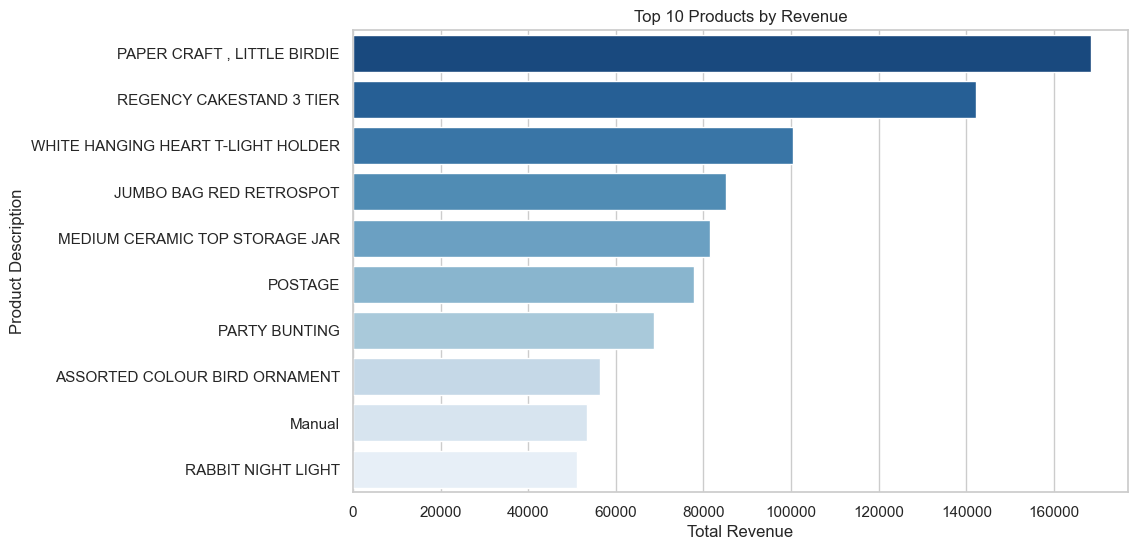

In [126]:
top_products_qty = df.groupby('Description')['Quantity'].sum().nlargest(10)
top_products_rev = df.groupby('Description')['Revenue'].sum().nlargest(10)

sns.barplot(x=top_products_rev.values, y=top_products_rev.index, palette='Blues_r')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Description')
plt.show()

## Insight 3: Whales/VIP Customers

C:\Users\Hello\AppData\Local\Temp\ipykernel_22020\4054515756.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_customers, x='Revenue', y='CustomerID', palette='Dark2', orient='h')


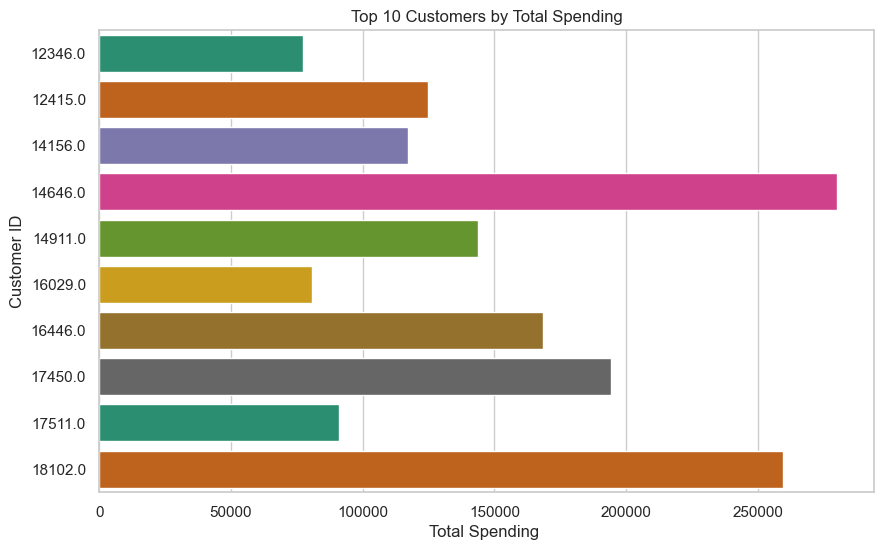

In [127]:

top_customers = df.groupby('CustomerID')['Revenue'].sum().nlargest(10).reset_index()

sns.barplot(data=top_customers, x='Revenue', y='CustomerID', palette='Dark2', orient='h')
plt.title('Top 10 Customers by Total Spending')
plt.xlabel('Total Spending ')
plt.ylabel('Customer ID')
plt.show()

##  Insight 4: Monthly Trend

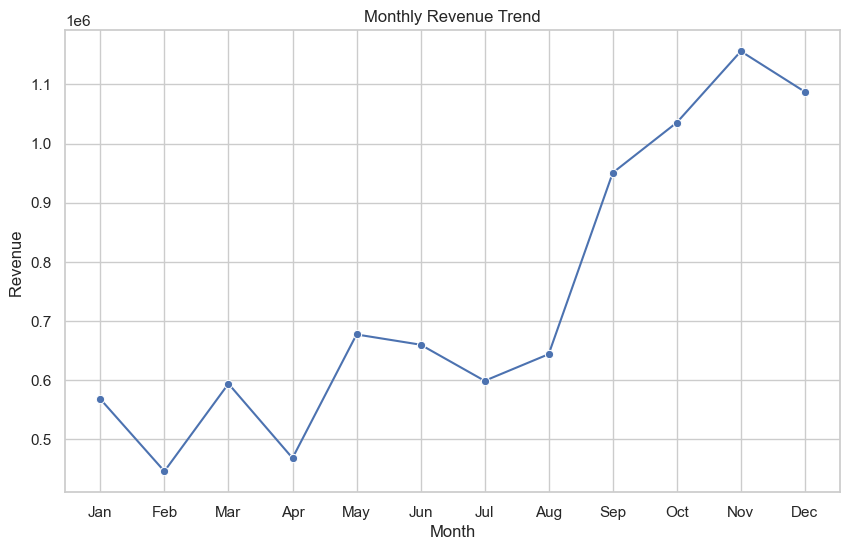

In [128]:
monthly_sales = df.groupby('Month')['Revenue'].sum()
weekday_sales = df.groupby('DayOfWeek')['Revenue'].sum()
hourly_sales = df.groupby('Hour')['Revenue'].sum()

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', color='b')
plt.title('Monthly Revenue Trend')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel('Revenue ')
plt.show()

## Insight 5 & 6: Weekday & Hourly Patterns

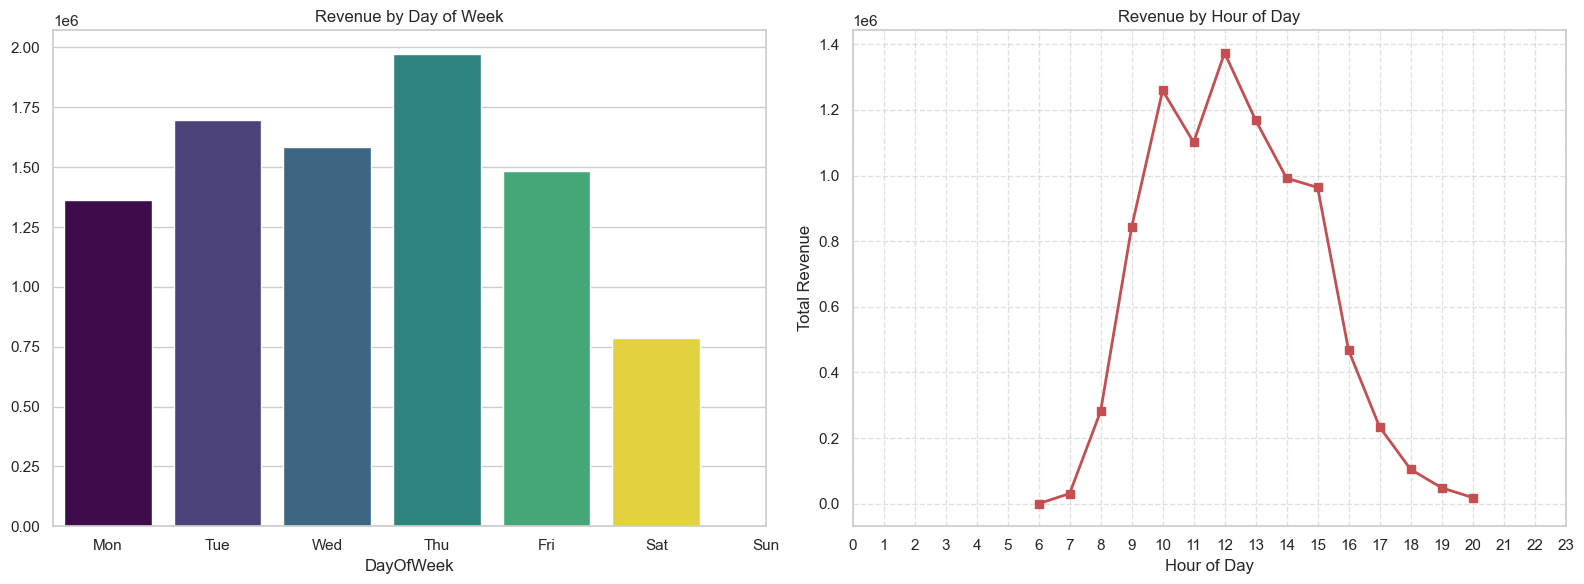

In [129]:
df['Hour'] = df['InvoiceDate'].dt.hour
hourly_sales = df.groupby('Hour')['Revenue'].sum()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(ax=axes[0], x=weekday_sales.index, y=weekday_sales.values, palette='viridis', hue=weekday_sales.index, legend=False)
axes[0].set_title('Revenue by Day of Week')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

axes[1].plot(hourly_sales.index, hourly_sales.values, marker='s', color='r', linewidth=2)
axes[1].set_title('Revenue by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Total Revenue')
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [130]:
print(hourly_sales)

Hour
6           4.250
7       31059.210
8      281997.790
9      842392.341
10    1259267.591
11    1101177.600
12    1373695.390
13    1168724.200
14     991992.821
15     963559.680
16     467380.560
17     233811.591
18     104744.990
19      48568.400
20      18832.480
Name: Revenue, dtype: float64


## Insight 7 & 8: Geographic Distribution

C:\Users\Hello\AppData\Local\Temp\ipykernel_22020\1831604034.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=country_stats['Revenue'], y=country_stats.index, palette='coolwarm')
C:\Users\Hello\AppData\Local\Temp\ipykernel_22020\1831604034.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=country_stats['CustomerID'], y=country_stats.index, palette='pastel')


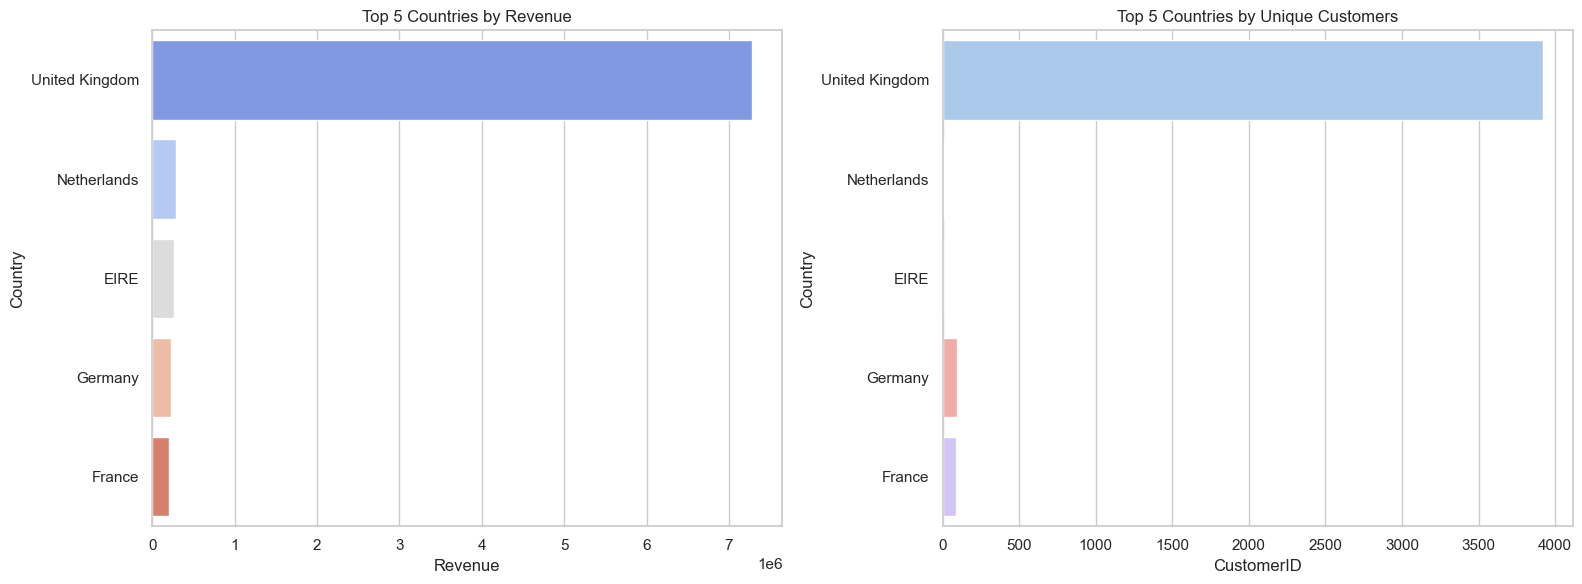

In [131]:
country_stats = df.groupby('Country').agg({'Revenue': 'sum', 'CustomerID': 'nunique'}).nlargest(5, 'Revenue')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(ax=axes[0], x=country_stats['Revenue'], y=country_stats.index, palette='coolwarm')
axes[0].set_title('Top 5 Countries by Revenue')

sns.barplot(ax=axes[1], x=country_stats['CustomerID'], y=country_stats.index, palette='pastel')
axes[1].set_title('Top 5 Countries by Unique Customers')
plt.tight_layout()
plt.show()

## Insight 9: Transaction Size Distribution

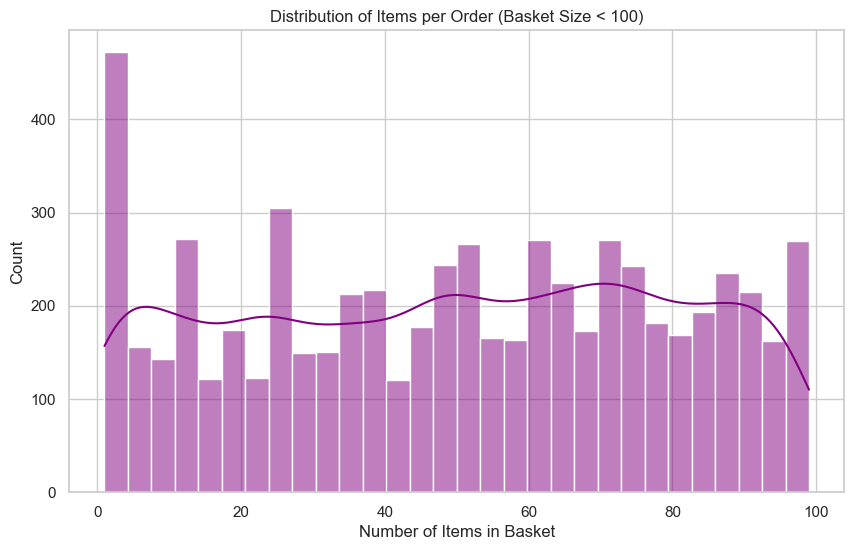

In [132]:

basket_size = df.groupby('InvoiceNo')['Quantity'].sum()
sns.histplot(basket_size[basket_size < 100], bins=30, kde=True, color='purple')
plt.title('Distribution of Items per Order (Basket Size < 100)')
plt.xlabel('Number of Items in Basket')
plt.show()

## Insight 10: Average Order Value (AOV) per Customer Distribution

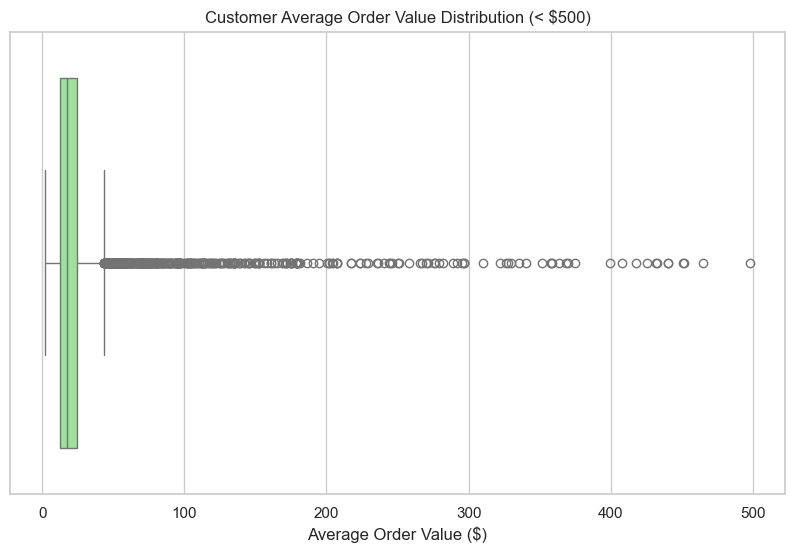

In [133]:
customer_aov = df.groupby('CustomerID')['Revenue'].mean()
sns.boxplot(x=customer_aov[customer_aov < 500], color='lightgreen')
plt.title('Customer Average Order Value Distribution (< $500)')
plt.xlabel('Average Order Value ($)')
plt.show()

# Customer Segmentation 

In [134]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'Revenue': 'sum'                                         # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
print("--- RFM Raw Features ---")
print(rfm.head())

--- RFM Raw Features ---
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


In [ ]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p, axis=1)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
print("\n--- Scaled Features Summary ---")
print(rfm_scaled_df.describe().round(2))


--- Scaled Features Summary ---
       Recency  Frequency  Monetary
count  4338.00    4338.00   4338.00
mean     -0.00      -0.00     -0.00
std       1.00       1.00      1.00
min      -2.34      -0.96     -4.00
25%      -0.66      -0.96     -0.68
50%       0.09      -0.36     -0.07
75%       0.84       0.65      0.66
max       1.56       5.86      4.73


### 
We selected the K-Means Clustering algorithm for this project due to its exceptional scalability and computational efficiency ($O(n)$) on retail transaction datasets. Furthermore, following the log-transformation and feature scaling of our RFM data, the clusters naturally tend to be spherical, making K-Means mathematically optimal. Unlike density-based methods (e.g., DBSCAN) which might produce highly unbalanced segments, K-Means provides actionable, well-defined customer profiles that the marketing team can directly target

In [136]:
print("Shape of rfm_scaled:", rfm_scaled.shape)
print("Number of unique customers in rfm:", rfm['CustomerID'].nunique())

Shape of rfm_scaled: (4338, 3)
Number of unique customers in rfm: 4338


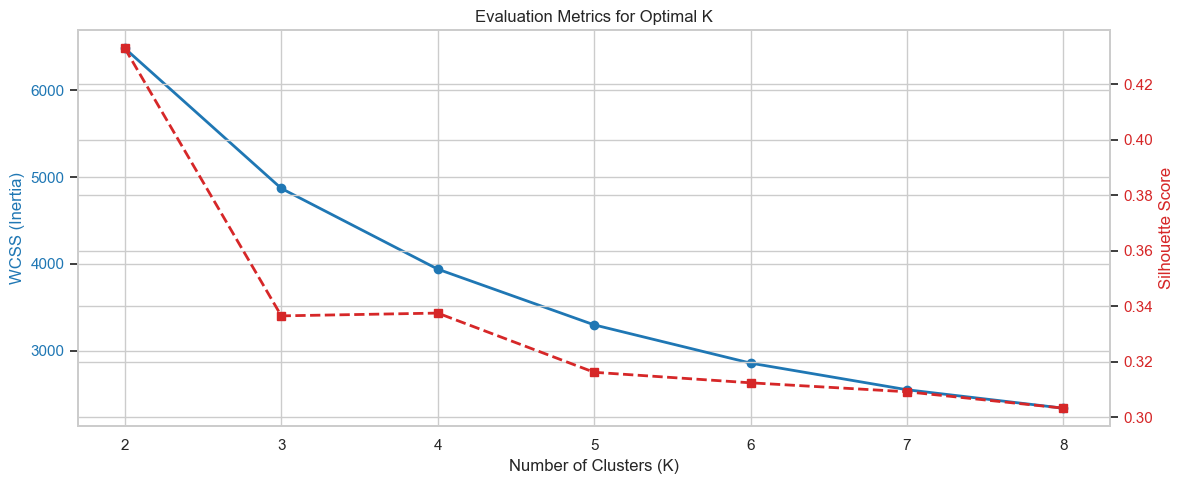

In [ ]:
wcss = []
silhouette_avg = []
k_range = range(2, 9) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(rfm_scaled, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS (Inertia)', color=color)
ax1.plot(k_range, wcss, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title('Evaluation Metrics for Optimal K')

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_avg, marker='s', color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.tight_layout()
plt.show()

In [139]:
optimal_k = 4 
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

rfm['Cluster'] = final_kmeans.fit_predict(rfm_scaled) 

cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

cluster_profile.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Customer_Count']
print(cluster_profile)

         Avg_Recency  Avg_Frequency  Avg_Monetary  Customer_Count
Cluster                                                          
0               12.2           13.8        8088.0             713
1              181.5            1.3         341.0            1622
2               17.7            2.2         557.3             837
3               71.6            4.1        1801.8            1166
